In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Online Retail.csv')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
11994,537354,22812,PACK 3 BOXES CHRISTMAS PANNETONE,2,12/6/2010 12:23,1.95,12748.0,United Kingdom
11995,537354,22733,3D TRADITIONAL CHRISTMAS STICKERS,3,12/6/2010 12:23,1.25,12748.0,United Kingdom
11996,537354,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,4,12/6/2010 12:23,2.55,12748.0,United Kingdom
11997,537359,22086,PAPER CHAIN KIT 50'S CHRISTMAS,12,12/6/2010 12:30,2.95,14825.0,United Kingdom


In [3]:
df.shape

(11999, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11999 entries, 0 to 11998
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    11999 non-null  str    
 1   StockCode    11999 non-null  str    
 2   Description  11957 non-null  str    
 3   Quantity     11999 non-null  int64  
 4   InvoiceDate  11999 non-null  str    
 5   UnitPrice    11999 non-null  float64
 6   CustomerID   8497 non-null   float64
 7   Country      11999 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 750.1 KB


In [5]:
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description      42
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     3502
Country           0
dtype: int64

In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,11999.000000,11999.000000,8497.000000
mean,7.516876,4.020363,15560.594327
std,95.645343,17.565273,1750.688790
min,-9360.000000,0.000000,12395.000000
25%,1.000000,1.250000,14293.000000
50%,2.000000,2.510000,15574.000000
75%,6.000000,4.240000,17062.000000
max,2880.000000,940.870000,18239.000000


In [7]:
df.duplicated().sum()

np.int64(224)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [11]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
11994,537354,22812,PACK 3 BOXES CHRISTMAS PANNETONE,2,12/6/2010 12:23,1.95,12748.0,United Kingdom,3.90
11995,537354,22733,3D TRADITIONAL CHRISTMAS STICKERS,3,12/6/2010 12:23,1.25,12748.0,United Kingdom,3.75
11996,537354,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,4,12/6/2010 12:23,2.55,12748.0,United Kingdom,10.20
11997,537359,22086,PAPER CHAIN KIT 50'S CHRISTMAS,12,12/6/2010 12:30,2.95,14825.0,United Kingdom,35.40


In [13]:
invoice_total=df.groupby("InvoiceNo")["TotalPrice"].sum()
average_purchase_value=invoice_total.mean()

In [14]:
purchase_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()


In [15]:
customer_lifetime_value = df.groupby('CustomerID')['TotalPrice'].sum()

In [16]:
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max()
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12395.0,2,1,346.10
12427.0,3,1,303.50
12431.0,5,1,358.25
12433.0,4,1,1919.14
12472.0,0,1,1631.30


In [17]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[1004.9999999999995, 735.924413263019, 399.1740102511112, 207.80136625175672, 160.0810352806473, 139.99598636016884, 119.16040221063389, 93.50479219687529, 85.69233527453665, 61.80687690892854]


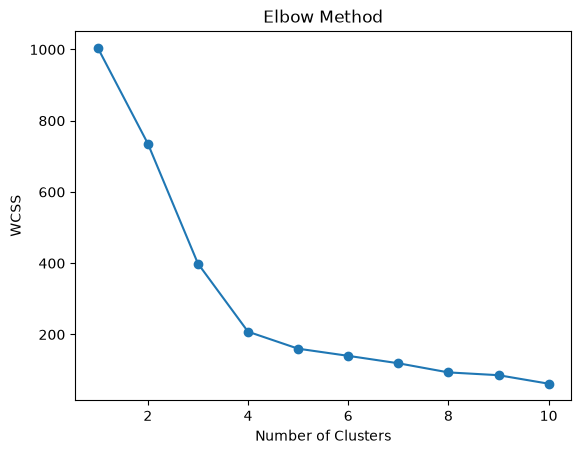

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'] = clusters

In [20]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,0.659420,1.260870,418.721957
1,3.769634,1.109948,370.189319
2,2.000000,4.200000,5721.256000
3,3.000000,34.000000,5391.210000


## Cluster Profile

The K-Means algorithm divided customers into four segments based on Recency, Frequency, and Monetary values.

* **Cluster 0 – Loyal / High-Value Customers:** active customers with frequent purchases and relatively high spending.
* **Cluster 1 – Inactive / At-Risk Customers:** customers who have not purchased for a long time and have low purchase frequency and spending.
* **Cluster 2 – VIP / Best Customers:** the most valuable customers, with very recent and frequent purchases and the highest spending.
* **Cluster 3 – Regular / Low-Value Customers:** customers with lower purchase frequency and spending.


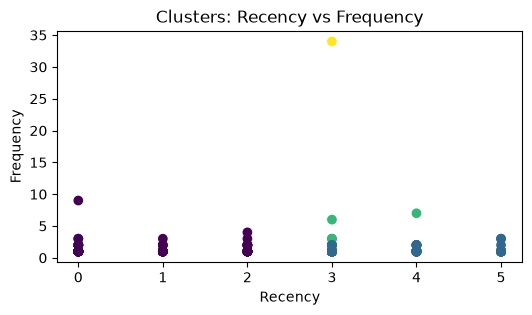

In [21]:
import matplotlib.pyplot as pl
plt.figure(figsize=(6,3))
plt.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Cluster'])
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Clusters: Recency vs Frequency')
plt.show()

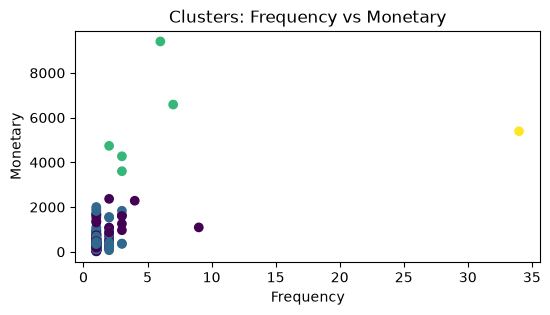

In [22]:
plt.figure(figsize=(6,3))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Clusters: Frequency vs Monetary')
plt.show()

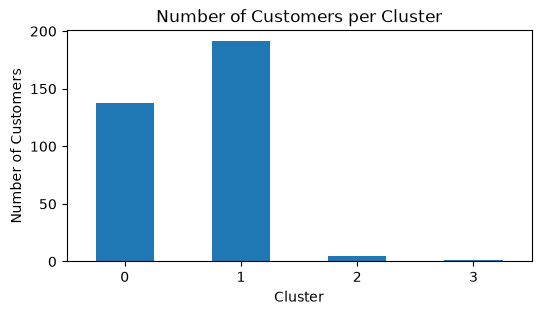

In [23]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()
plt.figure(figsize=(6,3))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers per Cluster')
plt.xticks(rotation=0)

plt.show()

Cluster 3 contains the largest number of customers, while Cluster 2 contains the smallest number of customers.


## Marketing Recommendations

* **Cluster 2 – VIP / Best Customers:** offer VIP rewards, exclusive products, and personalized offers to retain these valuable customers.
* **Cluster 0 – Loyal / High-Value Customers:** use loyalty rewards and cross-selling to encourage them to become VIP customers.
* **Cluster 3 – Regular / Low-Value Customers:** use discounts, bundles, and personalized recommendations to increase purchase frequency.
* **Cluster 1 – Inactive / At-Risk Customers:** use reactivation campaigns, special coupons, and reminder emails to bring these customers back.
